In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [3]:
df_list = []

for i in range(1, 10):
    file = f"w06-SBAnational{i:02d}.csv"
    temp = pd.read_csv(file, low_memory=False)
    df_list.append(temp)
    print(f"Loaded: {file} with {temp.shape[0]} rows and {temp.shape[1]} columns")

df = pd.concat(df_list, ignore_index=True)

print("Final shape:", df.shape)

Loaded: w06-SBAnational01.csv with 100000 rows and 28 columns
Loaded: w06-SBAnational02.csv with 100000 rows and 28 columns
Loaded: w06-SBAnational03.csv with 100000 rows and 28 columns
Loaded: w06-SBAnational04.csv with 100000 rows and 28 columns
Loaded: w06-SBAnational05.csv with 100000 rows and 28 columns
Loaded: w06-SBAnational06.csv with 100000 rows and 28 columns
Loaded: w06-SBAnational07.csv with 100000 rows and 28 columns
Loaded: w06-SBAnational08.csv with 100000 rows and 28 columns
Loaded: w06-SBAnational09.csv with 99164 rows and 28 columns
Final shape: (899164, 28)


In [4]:
# Basic overview
print(df.head())
print("\n")
print(df.dtypes)
print("\n")
print(df.isnull().sum())
print("\n")
print(df['MIS_Status'].value_counts(dropna=False))

   Unnamed: 0  LoanNr_ChkDgt                           Name          City  \
0           1     1000014003                 ABC HOBBYCRAFT    EVANSVILLE   
1           2     1000024006    LANDMARK BAR & GRILLE (THE)     NEW PARIS   
2           3     1000034009          WHITLOCK DDS, TODD M.   BLOOMINGTON   
3           4     1000044001  BIG BUCKS PAWN & JEWELRY, LLC  BROKEN ARROW   
4           5     1000054004    ANASTASIA CONFECTIONS, INC.       ORLANDO   

  State    Zip                           Bank BankState   NAICS ApprovalDate  \
0    IN  47711               FIFTH THIRD BANK        OH  451120    28-Feb-97   
1    IN  46526                1ST SOURCE BANK        IN  722410    28-Feb-97   
2    IN  47401        GRANT COUNTY STATE BANK        IN  621210    28-Feb-97   
3    OK  74012  1ST NATL BK & TR CO OF BROKEN        OK       0    28-Feb-97   
4    FL  32801        FLORIDA BUS. DEVEL CORP        FL       0    28-Feb-97   

  ApprovalFY  Term  NoEmp  NewExist  CreateJob  Retained

In [5]:
print(df['NAICS'].value_counts(dropna=False))

NAICS
0         201948
722110     27989
722211     19448
811111     14585
621210     14048
           ...  
221114         1
325180         1
333413         1
315280         1
922140         1
Name: count, Length: 1312, dtype: int64


In [6]:
print("BalanceGross value counts (sample):")
print(df['BalanceGross'].value_counts().head(10))

print("\nChgOffPrinGr value counts (sample):")
print(df['ChgOffPrinGr'].value_counts().head(10))

BalanceGross value counts (sample):
BalanceGross
$0.00           899150
$12,750.00           1
$827,875.00          1
$25,000.00           1
$37,100.00           1
$43,127.00           1
$84,617.00           1
$1,760.00            1
$115,820.00          1
$996,262.00          1
Name: count, dtype: int64

ChgOffPrinGr value counts (sample):
ChgOffPrinGr
$0.00           737152
$50,000.00        2110
$10,000.00        1865
$25,000.00        1371
$35,000.00        1345
$100,000.00       1028
$20,000.00         594
$30,000.00         492
$15,000.00         467
$5,000.00          356
Name: count, dtype: int64


In [7]:
# I had a doubt when I saw null Name rows, I thought they might be entirely blank so checking that here
null_name_rows = df[df['Name'].isna()]
print(f"Total rows where Name is null: {len(null_name_rows)}")

print("\nNull counts within those rows:")
print(null_name_rows.isnull().sum())

fully_blank = null_name_rows.isnull().all(axis=1).sum()
print(f"\nCompletely blank rows: {fully_blank}")

Total rows where Name is null: 14

Null counts within those rows:
Unnamed: 0            0
LoanNr_ChkDgt         0
Name                 14
City                  0
State                 0
Zip                   0
Bank                  0
BankState             0
NAICS                 0
ApprovalDate          0
ApprovalFY            0
Term                  0
NoEmp                 0
NewExist              0
CreateJob             0
RetainedJob           0
FranchiseCode         0
UrbanRural            0
RevLineCr             0
LowDoc                0
ChgOffDate           13
DisbursementDate      0
DisbursementGross     0
BalanceGross          0
MIS_Status            0
ChgOffPrinGr          0
GrAppv                0
SBA_Appv              0
dtype: int64

Completely blank rows: 0


In [8]:
# Cleaning the $ symbol from these columns
money_cols = ['DisbursementGross', 'GrAppv', 'SBA_Appv', 'BalanceGross']

for col in money_cols:
    df[col] = df[col].str.replace('$', '', regex=False)\
                     .str.replace(',', '', regex=False)\
                     .str.strip()\
                     .astype(float)


In [9]:
# checking for dirty values and fixing in this column
print(df['ApprovalFY'].unique())
print(df['ApprovalFY'].dtype)

[1997 1980 2006 1998 1999 2000 2001 1972 2003 2004 1978 1979 1981 2005
 1962 1982 1965 1966 1983 1973 1984 2007 1985 1986 1987 2008 1988 2009
 1989 1991 1990 1974 2010 1967 2011 1992 1993 2002 2012 2013 1994 '1993'
 '2003' '2013' '1994' '2014' '1975' '1977' '1974' '2004' '1978' '1979'
 '1976' '1968' '1967' '1981' '1982' '1983' '1984' '1980' '1976A' '1969'
 '1995' '1970' '2005' '1996' '1971' 1995 1977 1971 1996]
object


In [10]:
# Replacing the one dirty value
df['ApprovalFY'] = df['ApprovalFY'].replace('1976A', 1976)

# Converting everything to int
df['ApprovalFY'] = df['ApprovalFY'].astype(int)

print(df['ApprovalFY'].unique())
print(df['ApprovalFY'].dtype)

[1997 1980 2006 1998 1999 2000 2001 1972 2003 2004 1978 1979 1981 2005
 1962 1982 1965 1966 1983 1973 1984 2007 1985 1986 1987 2008 1988 2009
 1989 1991 1990 1974 2010 1967 2011 1992 1993 2002 2012 2013 1994 2014
 1975 1977 1976 1968 1969 1995 1970 1996 1971]
int64


In [11]:
# dropping rows where target is nulll and then encoding target

df = df[df['MIS_Status'].notna()].copy()
df['Default'] = (df['MIS_Status'] == 'CHGOFF').astype(int)
# P I F → 0, CHGOFF → 1

print("Target distribution after dropping nulls:")
print(df['Default'].value_counts())
print(df['Default'].value_counts(normalize=True).round(3))

Target distribution after dropping nulls:
Default
0    739609
1    157558
Name: count, dtype: int64
Default
0    0.824
1    0.176
Name: proportion, dtype: float64


In [12]:
# Fix Y/N binary columns of RevLineCr and LowDoc


print("RevLineCr unique:", df['RevLineCr'].unique())
print("LowDoc unique:", df['LowDoc'].unique())

# mapping
yn_map = {'Y': 1, 'N': 0}

df['RevLineCr'] = df['RevLineCr'].map(yn_map)
df['LowDoc'] = df['LowDoc'].map(yn_map)

# Anything not Y or N becomes NaN and then fill with 0 (a conservative assumption)
df['RevLineCr'] = df['RevLineCr'].fillna(0).astype(int)
df['LowDoc'] = df['LowDoc'].fillna(0).astype(int)

# as you can see initially there were lot of garbage value but after using map, they all became Nan and now we 
# fill the nulls with 0

RevLineCr unique: <ArrowStringArray>
['N', '0', 'Y', 'T', nan, '`', ',', '1', 'C', '3', '2', 'R', '7', 'A', '5',
 '.', '4', '-', 'Q']
Length: 19, dtype: str
LowDoc unique: <ArrowStringArray>
['Y', 'N', 'C', '1', nan, 'S', 'R', 'A', '0']
Length: 9, dtype: str


In [13]:
print("RevLineCr unique:", df['RevLineCr'].unique())
print("LowDoc unique:", df['LowDoc'].unique())

RevLineCr unique: [0 1]
LowDoc unique: [1 0]


In [14]:
# Fixing NewExist dirty values
# 1.0 = existing business, 2.0 = new business
# 136 nulls, I am filling with mode
df['NewExist'] = df['NewExist'].replace(0, pd.NA)
df['NewExist'] = df['NewExist'].fillna(df['NewExist'].mode()[0])
df['NewExist'] = df['NewExist'].astype(int)

In [15]:
df.head()

,Unnamed: 0,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,Default
0,1,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,84,4,2,0,0,1,0,0,1,NaN,28-Feb-99,60000.0,0.0,P I F,$0.00,60000.0,48000.0,0
1,2,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,60,2,2,0,0,1,0,0,1,NaN,31-May-97,40000.0,0.0,P I F,$0.00,40000.0,32000.0,0
2,3,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,180,7,1,0,0,1,0,0,0,NaN,31-Dec-97,287000.0,0.0,P I F,$0.00,287000.0,215250.0,0
3,4,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,60,2,1,0,0,1,0,0,1,NaN,30-Jun-97,35000.0,0.0,P I F,$0.00,35000.0,28000.0,0
4,5,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,240,14,1,7,7,1,0,0,0,NaN,14-May-97,229000.0,0.0,P I F,$0.00,229000.0,229000.0,0


In [16]:
# mapping as per dictionary then one hot encoding it.
df['NewExist'] = df['NewExist'].replace({
    1: 'Existing',
    2: 'New'
})

In [17]:
df = pd.get_dummies(df, columns=['NewExist'], dtype=int)

In [18]:
print("FranchiseCode unique:", df['FranchiseCode'].value_counts())

FranchiseCode unique: FranchiseCode
1        637395
0        208040
78760      3373
68020      1921
50564      1034
          ...  
62344         1
16326         1
2899          1
18701         1
15930         1
Name: count, Length: 2767, dtype: int64


In [19]:
df['BankState'] = df['BankState'].fillna(df['BankState'].mode()[0]) # filling the null values with mode (most common bank state)

In [20]:
df['HasFranchise'] = (df['FranchiseCode'] > 1).astype(int) 
# in FranchiseCode 0/1 means no and if any other value means yes
# we dont care about code rather only if franchise there or not

In [21]:
print("UrbanRural unique:", df['UrbanRural'].value_counts())

UrbanRural unique: UrbanRural
1    469281
0    322826
2    105060
Name: count, dtype: int64


In [22]:
df['UrbanRural'] = df['UrbanRural'].map({
    1: 'Urban',
    2: 'Rural',
    0: 'Unknown'
})

In [23]:
df = pd.get_dummies(df, columns=['UrbanRural'], dtype=int)

In [24]:
print("NAICS unique:", df['NAICS'].value_counts())

NAICS unique: NAICS
0         201667
722110     27941
722211     19435
811111     14539
621210     14034
           ...  
221114         1
325180         1
333413         1
315280         1
922140         1
Name: count, Length: 1312, dtype: int64


In [25]:
print(df['Term'].describe())
print(df['Term'].value_counts().sort_index().head(20))

count    897167.000000
mean        110.848592
std          78.900862
min           0.000000
25%          60.000000
50%          84.000000
75%         120.000000
max         569.000000
Name: Term, dtype: float64
Term
0       806
1      1604
2      1809
3      2107
4      2166
5      1861
6      3050
7      1759
8      1689
9      1873
10     1575
11     1716
12    16992
13     2050
14     1534
15     1576
16     1465
17     1481
18     1873
19     1546
Name: count, dtype: int64


### DROPPING ROWS BECAUSE OF MULITPLE INCONSISTENCIES

In [26]:
print(df['NoEmp'].describe())

count    897167.000000
mean         11.412562
std          73.793775
min           0.000000
25%           2.000000
50%           4.000000
75%          10.000000
max        9999.000000
Name: NoEmp, dtype: float64


In [27]:
print(df[['CreateJob', 'RetainedJob']].describe())

           CreateJob    RetainedJob
count  897167.000000  897167.000000
mean        8.444305      10.807308
std       236.950249     237.382398
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       1.000000
75%         1.000000       4.000000
max      8800.000000    9500.000000


In [28]:
print(df[df['NoEmp'] == 9999]['NoEmp'].count())

4


In [29]:
print(df[df['CreateJob'] > 500]['CreateJob'].count())
print(df[df['RetainedJob'] > 500]['RetainedJob'].count())

684
700


In [30]:
print(df[df['NoEmp'] > 500]['NoEmp'].count())

401


In [31]:
# Removing rows with invalid or meaningless values in loan term, employment, and job count columns
df = df[df['Term'] > 0]  
# Removing loans with 0 month term; 806 rows being affected, constituting 0.09% of the dataset

df = df[df['NoEmp'] != 9999]  
# Removing unknown employment values marked as 9999; 4 rows being affected, representing a negligible share of the dataset

df = df[df['NoEmp'] <= 500]  
# Keeping businesses within the SBA small-business employee limit; 401 rows being affected, representing 0.04% of the dataset

df = df[df['CreateJob'] <= 500]  
# Removing unusually high job creation values; 684 rows being affected, accounting for 0.07% of the dataset

df = df[df['RetainedJob'] <= 500]  
# Removing unusually high job retention values; 700 rows being affected, making up 0.07% of the dataset

print(df.shape)

(895268, 33)


In [32]:
df[df['NoEmp'] == 0]

,Unnamed: 0,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,Term,NoEmp,CreateJob,RetainedJob,FranchiseCode,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv,Default,NewExist_Existing,NewExist_New,HasFranchise,UrbanRural_Rural,UrbanRural_Unknown,UrbanRural_Urban
1089,1090,1007485003,Hoffman and Associates Dental,ORLANDO,FL,32826,WELLS FARGO BANK NATL ASSOC,SD,339116,1-Aug-03,2003,36,0,0,0,1,0,0,NaN,30-Sep-03,86000.0,0.0,P I F,$0.00,86000.0,43000.0,0,0,1,0,0,1,0
1092,1093,1007495006,Hoffman and Associates Dental,ORLANDO,FL,32826,WELLS FARGO BANK NATL ASSOC,SD,339116,1-Aug-03,2003,36,0,0,0,1,1,0,NaN,31-Dec-03,36857.0,0.0,P I F,$0.00,20000.0,10000.0,0,0,1,0,0,1,0
1463,1464,1009885009,"THE TIRE DEPOT, INC",BRANDON,MS,39047,TRUSTMARK NATIONAL BANK,MS,441320,15-Jan-04,2004,44,0,0,0,1,1,0,NaN,31-Aug-04,84168.0,0.0,P I F,$0.00,50000.0,25000.0,0,0,1,0,1,0,0
1517,1518,1010355000,Tropical Smoothie Cafe and Del,MADISON,AL,35758,WELLS FARGO BANK NATL ASSOC,SD,722211,9-Mar-04,2004,60,0,0,0,83882,0,0,NaN,31-Aug-04,125000.0,0.0,P I F,$0.00,125000.0,62500.0,0,0,1,1,0,0,1
1590,1591,1010865000,The Matterhorn - Ice Cream & C,COLLEGEVILLE,PA,19426,UNIVEST BANK AND TRUST CO.,PA,722213,26-Mar-04,2004,60,0,0,0,1,1,0,NaN,31-Jul-04,65003.0,0.0,P I F,$0.00,45000.0,22500.0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664272,664273,6728795005,JH Group LLC,PEARL CITY,HI,96782,"AMERICAN SAVINGS BANK, FSB",HI,722511,18-Mar-14,2014,60,0,7,7,0,0,0,NaN,18-Mar-14,200000.0,0.0,P I F,$0.00,200000.0,180000.0,0,0,1,0,0,0,1
669507,669508,6816425010,"Toasted Frog Fargo, LLC",FARGO,ND,58105,BANK FORWARD,ND,722511,6-May-14,2014,60,0,17,0,0,0,0,NaN,30-Jun-14,150000.0,0.0,P I F,$0.00,150000.0,75000.0,0,0,1,0,0,0,1
672918,672919,6878215001,"Onsite Contractors, LLC",Harrison,OH,45030,THE HUNTINGTON NATIONAL BANK,OH,237110,5-Jun-14,2014,60,0,0,0,0,1,0,NaN,5-Jun-14,17200.0,0.0,P I F,$0.00,17200.0,8600.0,0,1,0,0,0,0,1
673911,673912,6895265007,MARK DEMATTIA INCORPORATED,EWA BEACH,HI,96706,CENTRAL PACIFIC BANK,HI,492210,12-Jun-14,2014,60,0,0,0,0,0,0,NaN,12-Jun-14,50000.0,0.0,P I F,$0.00,50000.0,25000.0,0,0,1,0,0,0,1


## FEATURE ENGINEERING

In [33]:
# creating a few features to check whether loan size, processing time, 
# business size and local banking relationships are showing any useful patterns

In [34]:
# checking whether a higher sba guarantee is being associated with riskier loans
df['SBA_Ratio'] = df['SBA_Appv'] / df['GrAppv']  # a higher ratio may be showing that the bank is relying more on the sba guarantee

In [35]:
# checking how much of the approved amount is actually being disbursed
df['Disbursement_Ratio'] = df['DisbursementGross'] / df['GrAppv']  # a lower ratio may be showing that the loan amount changed during the process

In [36]:
# calculating the time being taken between approval and actual disbursement
df['ApprovalDate'] = pd.to_datetime(df['ApprovalDate'])
df['DisbursementDate'] = pd.to_datetime(df['DisbursementDate'])
df['Processing_Days'] = (df['DisbursementDate'] - df['ApprovalDate']).dt.days  
# longer processing time may be showing that the loan was taking more time to complete

In [37]:
# combining created and retained jobs to get one overall measure of job impact
df['Total_Jobs'] = df['CreateJob'] + df['RetainedJob']  # looking at the total number of jobs being created or retained by the business

# checking the job impact relative to the size of the business
df['Jobs_Per_Employee'] = np.where(
    df['NoEmp'] == 0,
    df['Total_Jobs'] / 1,
    df['Total_Jobs'] / df['NoEmp']
)  # comparing job impact with business size while avoiding division by zero

In [38]:
# checking whether being in the same state as the bank is showing any difference in default risk
df['Same_State'] = (df['State'] == df['BankState']).astype(int)  # marking loans where the borrower and bank are operating in the same state

# grouping loan terms to check whether different loan durations are showing different risk patterns
df['Term_Bucket'] = pd.cut(
    df['Term'],
    bins=[0, 36, 84, 600],
    labels=['Short', 'Medium', 'Long']
)  # grouping terms into short, medium and long duration loans to capture possible non-linear patterns


In [39]:
print(df.shape)
print(df[['SBA_Ratio', 'Disbursement_Ratio', 'Processing_Days',
          'Total_Jobs', 'Jobs_Per_Employee', 'Same_State', 'Term_Bucket']].head())

(895268, 40)
   SBA_Ratio  Disbursement_Ratio  Processing_Days  Total_Jobs  \
0       0.80                 1.0            730.0           0   
1       0.80                 1.0             92.0           0   
2       0.75                 1.0            306.0           0   
3       0.80                 1.0            122.0           0   
4       1.00                 1.0             75.0          14   

   Jobs_Per_Employee  Same_State Term_Bucket  
0                0.0           0      Medium  
1                0.0           1      Medium  
2                0.0           1        Long  
3                0.0           1      Medium  
4                1.0           1        Long  


In [40]:
# Mapping instead of dropping NAICS even though the full code is too granular to use directly,
# the 2-digit sector still carries meaningful signal about the broader industry, which is a known
# driver of default risk, so collapsing to sector level keeps that information instead of losing it

In [41]:
df['NAICS_Sector'] = df['NAICS'].astype(str).str[:2]

In [42]:
df['NAICS_Sector'].value_counts()

NAICS_Sector
0     200755
44     84454
81     72319
54     67841
72     67442
23     66351
62     55213
42     48598
45     42337
33     38138
56     32465
48     20166
32     17878
71     14594
53     13563
31     11769
51     11346
52      9460
11      8987
61      6393
49      2206
21      1850
22       661
55       255
92       227
Name: count, dtype: int64

In [43]:
# Mapping NAICS 2-digit sector codes to sector names
# Source: U.S. Census Bureau NAICS (https://www.census.gov/naics/)
naics_map = {
    '0': 'Unknown', '11': 'Agriculture', '21': 'Mining',
    '22': 'Utilities', '23': 'Construction', '31': 'Manufacturing',
    '32': 'Manufacturing', '33': 'Manufacturing', '42': 'Wholesale Trade',
    '44': 'Retail Trade', '45': 'Retail Trade', '48': 'Transportation',
    '49': 'Transportation', '51': 'Information', '52': 'Finance & Insurance',
    '53': 'Real Estate', '54': 'Professional Services', '55': 'Management',
    '56': 'Admin & Support', '61': 'Education', '62': 'Healthcare',
    '71': 'Arts & Recreation', '72': 'Accommodation & Food',
    '81': 'Other Services', '92': 'Public Administration'
}

In [44]:
df['NAICS_Sector'] = df['NAICS_Sector'].map(naics_map)
df = pd.get_dummies(df, columns=['NAICS_Sector'], dtype=int)

In [45]:
drop_cols = [
    'Unnamed: 0',       # removing duplicate index
    'LoanNr_ChkDgt',    # removing loan id
    'Name',             # removing free text
    'City',             # removing granular location
    'Zip',              # removing granular location
    'Bank',             # removing high-cardinality column
    'ApprovalDate',     # already using in Processing_Days
    'DisbursementDate', # already using in Processing_Days
    'ChgOffDate',       # removing leakage
    'BalanceGross',     # removing near-zero variance column
    'ChgOffPrinGr',     # removing target leakage
    'MIS_Status',       # already replacing with Default
    'FranchiseCode',    # already one-hot encoding
    'BankState',        # already using in Same_State
    'CreateJob',        # already using in Total_Jobs
    'RetainedJob',      # already using in Total_Jobs
]

df.drop(columns=drop_cols, inplace=True)

print(df.shape)
print(df.columns.tolist())

(895268, 45)
['State', 'NAICS', 'ApprovalFY', 'Term', 'NoEmp', 'RevLineCr', 'LowDoc', 'DisbursementGross', 'GrAppv', 'SBA_Appv', 'Default', 'NewExist_Existing', 'NewExist_New', 'HasFranchise', 'UrbanRural_Rural', 'UrbanRural_Unknown', 'UrbanRural_Urban', 'SBA_Ratio', 'Disbursement_Ratio', 'Processing_Days', 'Total_Jobs', 'Jobs_Per_Employee', 'Same_State', 'Term_Bucket', 'NAICS_Sector_Accommodation & Food', 'NAICS_Sector_Admin & Support', 'NAICS_Sector_Agriculture', 'NAICS_Sector_Arts & Recreation', 'NAICS_Sector_Construction', 'NAICS_Sector_Education', 'NAICS_Sector_Finance & Insurance', 'NAICS_Sector_Healthcare', 'NAICS_Sector_Information', 'NAICS_Sector_Management', 'NAICS_Sector_Manufacturing', 'NAICS_Sector_Mining', 'NAICS_Sector_Other Services', 'NAICS_Sector_Professional Services', 'NAICS_Sector_Public Administration', 'NAICS_Sector_Real Estate', 'NAICS_Sector_Retail Trade', 'NAICS_Sector_Transportation', 'NAICS_Sector_Unknown', 'NAICS_Sector_Utilities', 'NAICS_Sector_Wholesale T

### SOME SANITY CHECKS

In [46]:
print(df.isnull().sum()[df.isnull().sum() > 0])

State                13
Processing_Days    2171
dtype: int64


In [47]:
# Check for negative values — disbursed before approved
print(df[df['Processing_Days'] < 0]['Processing_Days'].count())

# Check for extreme values
print(df['Processing_Days'].describe())

816
count    893097.000000
mean        113.006869
std         222.775529
min      -36495.000000
25%          30.000000
50%          59.000000
75%         119.000000
max       24132.000000
Name: Processing_Days, dtype: float64


In [48]:
# Check if any loans have SBA guarantee greater than loan amount
print(df[df['SBA_Ratio'] > 1]['SBA_Ratio'].count())

0


In [49]:
# Processing_Days checking here, since the .describe() showed lot of suspicious values

percentiles = [50, 75, 90, 95, 99, 99.5, 99.9, 100]

for p in percentiles:
    print(f"{p}th percentile: {np.percentile(df['Processing_Days'].dropna(), p):.0f} days")

# Also check how many rows are above various thresholds
thresholds = [365, 500, 730, 1000, 2000]

for t in thresholds:
    count = (df['Processing_Days'] > t).sum()
    print(f"Above {t} days: {count} rows ({count/len(df)*100:.3f}%)")

50th percentile: 59 days
75th percentile: 119 days
90th percentile: 258 days
95th percentile: 407 days
99th percentile: 897 days
99.5th percentile: 1139 days
99.9th percentile: 1905 days
100th percentile: 24132 days
Above 365 days: 54209 rows (6.055%)
Above 500 days: 29438 rows (3.288%)
Above 730 days: 13802 rows (1.542%)
Above 1000 days: 7305 rows (0.816%)
Above 2000 days: 769 rows (0.086%)


In [50]:
# Fixing all the columns here 

# dropping State as too high-cardinality to encode cleanly, also it would be too much time taking but would love to learn 
# how this wourld have been achieved in real world;
# the borrower-vs-lender relationship signal is already captured in Same_State
df.drop(columns=['State'], inplace=True)


# Dropping negative and null Processing_Days, also anything above 
df = df[df['Processing_Days'] >= 0]
df = df[df['Processing_Days'].notna()]

# Dropping rows where Processing_Days exceeds 730 days (2 years)
# Beyond 2 years of processing time is not a legitimate SBA loan delay
# Only 13,802 rows affected — 1.542% of the dataset, safe to drop
df = df[df['Processing_Days'] <= 730]

# Ordinal encoding Term_Bucket
term_map = {'Short': 1, 'Medium': 2, 'Long': 3}
df['Term_Bucket'] = df['Term_Bucket'].map(term_map)

print(df.shape)
print(df['Term_Bucket'].value_counts())
print(df['Processing_Days'].describe())

(878479, 44)
Term_Bucket
2    440857
3    335275
1    102347
Name: count, dtype: int64
count    878479.000000
mean         97.385852
std         113.410555
min           0.000000
25%          30.000000
50%          58.000000
75%         114.000000
max         730.000000
Name: Processing_Days, dtype: float64


In [51]:
print(df.isnull().sum()[df.isnull().sum() > 0])
print(df.dtypes)

Series([], dtype: int64)
NAICS                                    int64
ApprovalFY                               int64
Term                                     int64
NoEmp                                    int64
RevLineCr                                int64
LowDoc                                   int64
DisbursementGross                      float64
GrAppv                                 float64
SBA_Appv                               float64
Default                                  int64
NewExist_Existing                        int64
NewExist_New                             int64
HasFranchise                             int64
UrbanRural_Rural                         int64
UrbanRural_Unknown                       int64
UrbanRural_Urban                         int64
SBA_Ratio                              float64
Disbursement_Ratio                     float64
Processing_Days                        float64
Total_Jobs                               int64
Jobs_Per_Employee                  

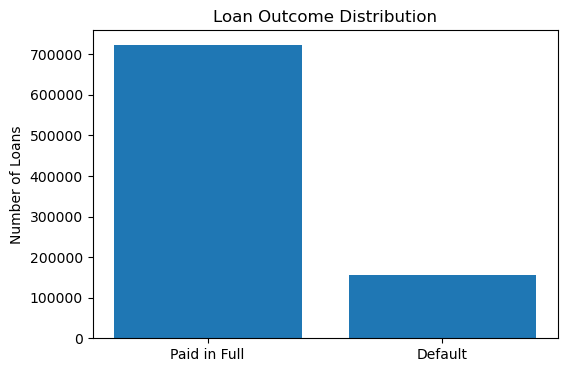

In [52]:
target = df['Default'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Paid in Full', 'Default'], target.values)

plt.title('Loan Outcome Distribution')
plt.ylabel('Number of Loans')
plt.show()

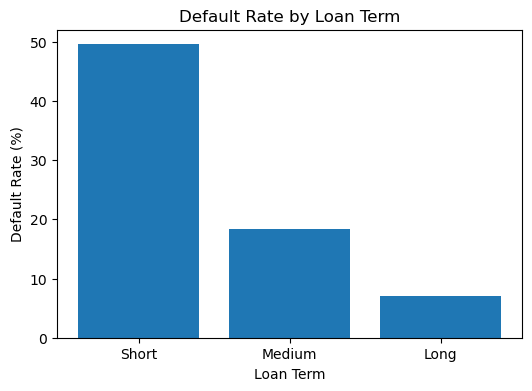

In [53]:
term_default = df.groupby('Term_Bucket')['Default'].mean() * 100

term_default.index = ['Short', 'Medium', 'Long']

plt.figure(figsize=(6, 4))
plt.bar(term_default.index, term_default.values)

plt.title('Default Rate by Loan Term')
plt.ylabel('Default Rate (%)')
plt.xlabel('Loan Term')

plt.show()

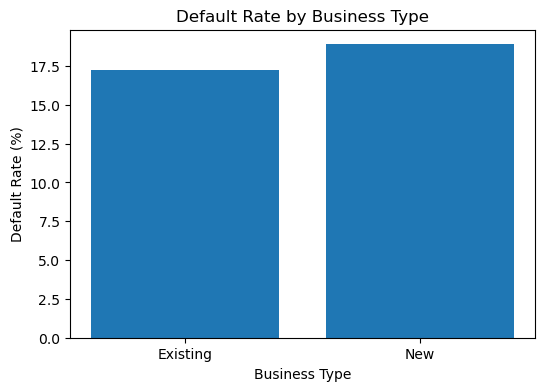

In [54]:
newexist_default = {
    'Existing': df.loc[df['NewExist_Existing'] == 1, 'Default'].mean() * 100,
    'New': df.loc[df['NewExist_New'] == 1, 'Default'].mean() * 100
}

plt.figure(figsize=(6, 4))
plt.bar(newexist_default.keys(), newexist_default.values())

plt.title('Default Rate by Business Type')
plt.ylabel('Default Rate (%)')
plt.xlabel('Business Type')

plt.show()

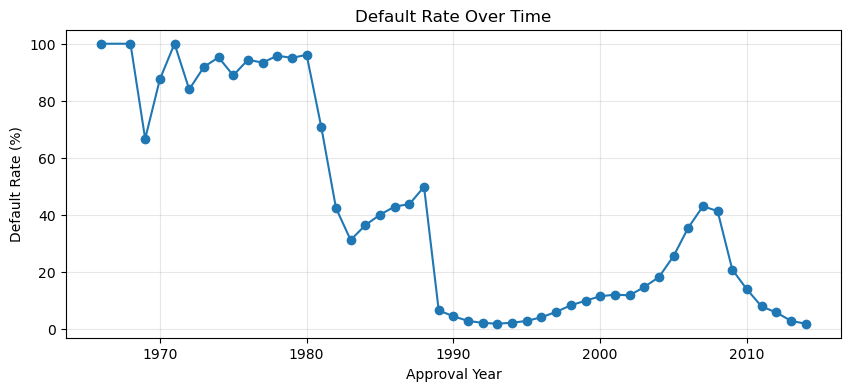

In [55]:
yearly_default = df.groupby('ApprovalFY')['Default'].mean() * 100

plt.figure(figsize=(10, 4))
plt.plot(yearly_default.index, yearly_default.values, marker='o')

plt.title('Default Rate Over Time')
plt.xlabel('Approval Year')
plt.ylabel('Default Rate (%)')
plt.grid(alpha=0.3)

plt.show()

# MAKING THE MODEL

In [56]:
import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [57]:
# SpZit once test set remains untouched
X = df.drop(columns='Default').copy()
y = df['Default'].astype(int)

In [58]:
# Train/Test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [59]:
# VALIDATION SPLIT
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

In [60]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight_value = neg / pos
scale_pos_weight_value

np.float64(4.645519540506888)

In [61]:
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_value,
    tree_method='hist',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

In [63]:
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100
)

[0]	validation_0-auc:0.93634
[100]	validation_0-auc:0.96572
[200]	validation_0-auc:0.97217
[300]	validation_0-auc:0.97492
[400]	validation_0-auc:0.97622
[500]	validation_0-auc:0.97721
[600]	validation_0-auc:0.97792
[700]	validation_0-auc:0.97843
[800]	validation_0-auc:0.97881
[900]	validation_0-auc:0.97913
[1000]	validation_0-auc:0.97936
[1100]	validation_0-auc:0.97959
[1200]	validation_0-auc:0.97975
[1300]	validation_0-auc:0.97991
[1400]	validation_0-auc:0.98003
[1500]	validation_0-auc:0.98015
[1600]	validation_0-auc:0.98023
[1700]	validation_0-auc:0.98032
[1800]	validation_0-auc:0.98039
[1900]	validation_0-auc:0.98043
[1999]	validation_0-auc:0.98048


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,'auc'


In [64]:
print("Best iteration:", model.best_iteration)

Best iteration: 1995


In [65]:
# model evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print("\n", classification_report(y_test, y_pred))
print("\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9349387578544759
Precision: 0.7538156130762091
Recall: 0.9395263648340348
F1: 0.8364874336637629
ROC-AUC: 0.9809822936354312
PR-AUC: 0.9198598387805043

               precision    recall  f1-score   support

           0       0.99      0.93      0.96    144575
           1       0.75      0.94      0.84     31121

    accuracy                           0.93    175696
   macro avg       0.87      0.94      0.90    175696
weighted avg       0.95      0.93      0.94    175696


 [[135026   9549]
 [  1882  29239]]


# Model Improvement and Evaluation

### What are we trying to do?

The model is already giving strong results, so here I am not just trying to increase the AUC.

I am testing whether the model can be improved further and whether the current results are reliable and useful for the credit-risk problem.

Some of the experiments here include:

- Increasing the number of estimators
- Testing different prediction thresholds
- Checking the precision/recall trade-off
- Using cross-validation to check model stability
- Checking other aspects of model performance if needed

## Increasing the number of estimators

### Testing with 3,000 estimators

The previous model had `n_estimators=2000` and the best iteration was `1997`, so I wanted to check whether the model could still improve if I allowed more boosting rounds.

Here I increased `n_estimators` to `3000` while keeping the other parameters the same. Early stopping is still set to 50 rounds.

In [66]:
model_3000 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_value,
    tree_method='hist',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

model_3000.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=100
)

print("Best iteration:", model_3000.best_iteration)

[0]	validation_0-auc:0.93634
[100]	validation_0-auc:0.96572
[200]	validation_0-auc:0.97217
[300]	validation_0-auc:0.97492
[400]	validation_0-auc:0.97622
[500]	validation_0-auc:0.97721
[600]	validation_0-auc:0.97792
[700]	validation_0-auc:0.97843
[800]	validation_0-auc:0.97881
[900]	validation_0-auc:0.97913
[1000]	validation_0-auc:0.97936
[1100]	validation_0-auc:0.97959
[1200]	validation_0-auc:0.97975
[1300]	validation_0-auc:0.97991
[1400]	validation_0-auc:0.98003
[1500]	validation_0-auc:0.98015
[1600]	validation_0-auc:0.98023
[1700]	validation_0-auc:0.98032
[1800]	validation_0-auc:0.98039
[1900]	validation_0-auc:0.98043
[2000]	validation_0-auc:0.98048
[2100]	validation_0-auc:0.98053
[2200]	validation_0-auc:0.98057
[2300]	validation_0-auc:0.98061
[2400]	validation_0-auc:0.98064
[2500]	validation_0-auc:0.98067
[2600]	validation_0-auc:0.98070
[2700]	validation_0-auc:0.98073
[2800]	validation_0-auc:0.98074
[2879]	validation_0-auc:0.98074
Best iteration: 2829


### Result

The model did not stop before reaching 3,000 estimators in the earlier run. The best iteration was **2993**, which was very close to the maximum of 3,000.

After restarting the notebook and running the same code again, the best iteration was **2829**. The validation AUC was still almost the same, around **0.98074**.

The validation AUC kept improving slowly throughout the training:

- At 2,000 iterations → AUC ≈ **0.98048**
- At 2,500 iterations → AUC ≈ **0.98067**
- At 2,800 iterations → AUC ≈ **0.98074**
- Best iteration → **2829**, AUC ≈ **0.98074**

The exact best iteration changed between runs, but the final AUC was almost identical. This is because the AUC improvements become extremely small at higher iterations, so small numerical differences can change the exact stopping point.

The main takeaway is that the previous 2,000-estimator model had not completely plateaued. Increasing the number of estimators gave a small improvement, but the gains became smaller as more trees were added.

Since the improvement is very small, there is probably not much value in continuously increasing the estimator limit just to get a slightly higher AUC.

## THRESHOLD ANALYSIS


Here I am checking how changing the classification threshold affects precision, recall, and F1.

The default threshold is 0.5, but it is not always the best threshold for a business problem. Since this is a credit-risk model, changing the threshold can change how many actual defaulters we catch and how many good borrowers we incorrectly flag.


In [67]:
threshold_results = []

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, y_pred_threshold),
        'Recall': recall_score(y_test, y_pred_threshold),
        'F1': f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.2,0.590424,0.977089,0.736066
1,0.3,0.655809,0.965875,0.781200
2,0.4,0.709645,0.953954,0.813860
3,0.5,0.753816,0.939526,0.836487
4,0.6,0.793184,0.921307,0.852458
5,0.7,0.832929,0.892613,0.861738


The results show a clear trade-off:

- At **0.2**, recall is very high at **0.977**, but precision is only **0.590**. The model catches almost all defaulters, but also flags many loans that do not actually default.
- At **0.5**, precision is **0.754** and recall is **0.940**. This is the current/default threshold.
- At **0.7**, precision increases to **0.833**, while recall falls to **0.893**. So the model makes fewer false-positive predictions, but also misses more actual defaults.

The highest F1 among the tested thresholds is still at **0.7**, with an F1 of **0.862**.

However, F1 alone should not decide the threshold here. In credit risk, recall is also important because missing an actual defaulter can result in a financial loss.

So the threshold depends on what we want to prioritize:

- Lower threshold → catch more defaults, but flag more good borrowers.
- Higher threshold → fewer false alarms, but miss more actual defaults.

For this project, I will keep the threshold comparison as part of the analysis rather than automatically changing the threshold to 0.7 just because it has the highest F1.

In [ ]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=3000,
    learning_rate=0.03,
    scale_pos_weight=scale_pos_weight_value,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_child_weight': [1, 2, 3, 4, 5, 6, 7],
    'subsample': [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0],
    'colsample_bytree': [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0],
    'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring='roc_auc',
    cv=4,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

### Adjusting the RandomizedSearchCV setup

The first RandomizedSearchCV setup was taking much longer than expected and there was no individual fit output even after a few minutes.

I did some research to understand why this was happening. The search was running 40 XGBoost fits, and each fit could use up to 3,000 estimators. I also noticed that both XGBoost and RandomizedSearchCV were set to use all available CPU cores.

So I changed the setup to:

- Reduce `n_estimators` from 3,000 back to 2,000
- Set XGBoost `n_jobs=1`
- Keep `RandomizedSearchCV` `n_jobs=-1`. I set XGBoost `n_jobs=1` so that each individual model uses one CPU core, while `RandomizedSearchCV` uses `n_jobs=-1` to run multiple model fits in parallel. This avoids both levels trying to use all CPU cores at the same time.
- Keep 10 random combinations and 4-fold cross-validation

This should make the search more manageable while still keeping the estimator count consistent with the earlier model.

### Cross-validation

I initially tried using `RandomizedSearchCV` to search for better hyperparameters. However, the search was computationally expensive because it required training many XGBoost models across multiple folds, with each model using a large number of estimators.

Even after reducing the number of parameter combinations, the search was taking too long and was putting a high computational load on the system.

Instead of continuing with a large hyperparameter search, I used **5-fold Stratified K-Fold cross-validation** with the current model parameters.

This allows me to check whether the model's ROC-AUC is stable across different subsets of the training data, without having to train a large number of different hyperparameter combinations.

### Why Stratified K-Fold?

Since this is a binary classification problem with an imbalanced target, I used `StratifiedKFold` instead of regular K-Fold.

Stratification keeps the proportion of default and non-default cases approximately similar in each fold.

This gives a more consistent evaluation across the folds and makes the cross-validation results more reliable for this classification problem.

In [70]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_value,
    tree_method='hist',
    random_state=42,
    n_jobs=1
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print("ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

ROC-AUC scores: [0.98067676 0.98116321 0.98036317 0.98101067 0.98064011]
Mean ROC-AUC: 0.9807707842542334
Std ROC-AUC: 0.0002841172866132956


### Cross-validation results

The model was evaluated using 5-fold Stratified K-Fold cross-validation.

The ROC-AUC scores across the five folds were:

- Fold 1 → **0.98068**
- Fold 2 → **0.98116**
- Fold 3 → **0.98036**
- Fold 4 → **0.98101**
- Fold 5 → **0.98064**

The mean ROC-AUC was **0.98077**, with a standard deviation of **0.00028**.

The scores are very close to each other, and the low standard deviation shows that the model's ROC-AUC is very consistent across the different folds.

This also supports the earlier result of around **0.98 ROC-AUC**, since the cross-validation performance is almost the same across different subsets of the training data.

So, the model appears to have stable ranking performance rather than relying heavily on one particular train-validation split.

## FEATURE IMPORTANCE

In [73]:
importance_2000 = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance_3000 = pd.Series(
    model_3000.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

In [74]:
print("Model 2000:")
print(importance_2000.head(15))

print("\nModel 3000:")
print(importance_3000.head(15))

Model 2000:
Term                                 0.187238
Term_Bucket                          0.129299
ApprovalFY                           0.103414
UrbanRural_Unknown                   0.100464
Same_State                           0.091881
SBA_Ratio                            0.066162
UrbanRural_Urban                     0.032133
RevLineCr                            0.028620
NAICS_Sector_Healthcare              0.018984
LowDoc                               0.017185
Disbursement_Ratio                   0.014518
GrAppv                               0.013641
NAICS_Sector_Retail Trade            0.012173
SBA_Appv                             0.012163
NAICS_Sector_Accommodation & Food    0.011655
dtype: float32

Model 3000:
Term                                 0.190274
Term_Bucket                          0.126045
ApprovalFY                           0.100066
UrbanRural_Unknown                   0.097625
Same_State                           0.085950
SBA_Ratio                            0.0

### Feature Importance

I compared the feature importance from the 2,000-estimator and 3,000-estimator models to check whether adding more trees changed the features being used by the model.

The feature importance rankings were very similar across both models. `Term`, `Term_Bucket`, `ApprovalFY`, `UrbanRural_Unknown`, `Same_State`, and `SBA_Ratio` were the most important features in both models.

The exact importance values changed slightly, but there was no major change in the overall ranking.

This suggests that increasing the number of estimators did not fundamentally change the patterns learned by the model. The additional trees mainly made small adjustments to the existing model rather than producing a completely different feature pattern.

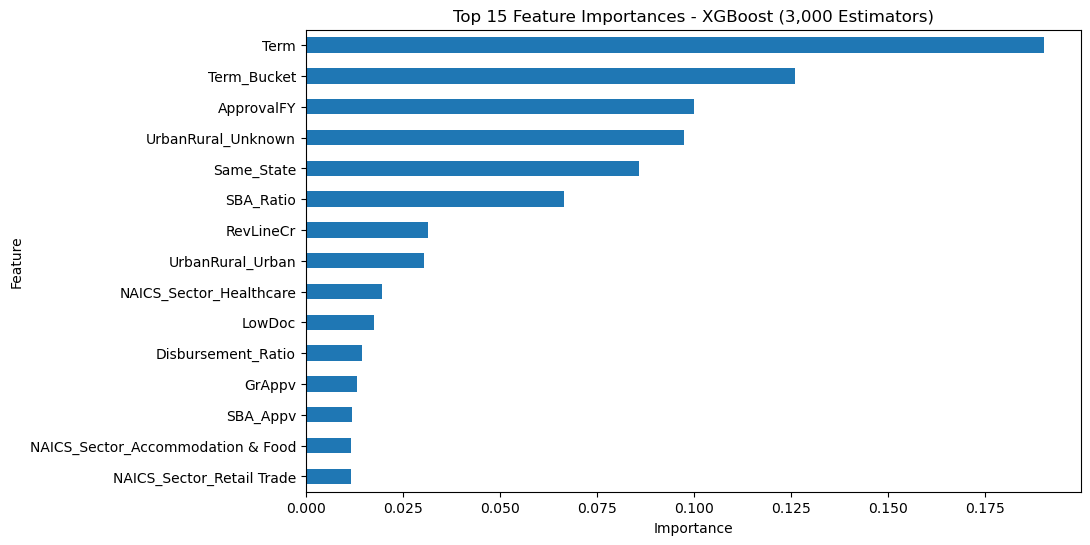

In [75]:

plt.figure(figsize=(10, 6))

importance_3000.head(15).sort_values().plot(kind='barh')

plt.title("Top 15 Feature Importances - XGBoost (3,000 Estimators)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Predictions - 2,000 estimators
y_pred_2000 = model.predict(X_test)
y_prob_2000 = model.predict_proba(X_test)[:, 1]

# Predictions - 3,000 estimators
y_pred_3000 = model_3000.predict(X_test)
y_prob_3000 = model_3000.predict_proba(X_test)[:, 1]


def get_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }


results = pd.DataFrame({
    "XGBoost 2,000": get_metrics(y_test, y_pred_2000, y_prob_2000),
    "XGBoost 3,000": get_metrics(y_test, y_pred_3000, y_prob_3000)
}).T

results.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
"XGBoost 2,000",0.9349,0.7538,0.9395,0.8365,0.9810,0.9199
"XGBoost 3,000",0.9361,0.7581,0.9390,0.8389,0.9812,0.9211
